# EDA

## Введение и задача

Задача: Анализ данных о населении, площади и аббревиатурах штатов США для выявления ключевых факторов, влияющих на плотность населения штатов, и сравнение штатов по этим показателям

Вопросы для анализа:  
1. Определить пиковые года по количеству населения;
2. Как различаются штаты по плотности населения;
3. Классифицировать штаты по плотности населения;
4. Динамика численности населения с классификацией популяции штатов;
5. Смотрим только население старше 18 лет.

---

https://pypi.org/project/jupyter-black/

In [ ]:
# Чтобы установить библиотеку - убери коммент и выполни код.
# При отправке кода ревьюеру важно убрать коммент, т.к. если у ревьюера
# нет этой библиотеки, то код упадёт в ошибку.

#!pip install jupyter-black

In [ ]:
# импортим новую библиотеку и запускаем её
#import jupyter_black

#jupyter_black.load()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from matplotlib.colors import (
    LinearSegmentedColormap,
)  # поможет расскарсить датафрейм см. ниже :)

warnings.filterwarnings("ignore")  # бережем глаза от ненужных предупреждений

In [ ]:
#df_full = pd.read_csv("df_full.csv")
url='https://drive.google.com/file/d/10gl8RmuVeam_G4LHResb0OOaCWR4WuzM/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_areas = pd.read_csv(url)

url='https://drive.google.com/file/d/1JXxhyLFZq8ywPvT8moeSnXkfDg-mZp2R/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_population = pd.read_csv(url)

url='https://drive.google.com/file/d/1QrzSKrRwaMb5UZwOWDbFhZcn-xk5QhJi/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_full = pd.read_csv(url)

url='https://drive.google.com/file/d/1w-FCOqmU5gQ2i6jBILAO7da1t3famI6D/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_temp = pd.read_csv(url, sep='\t')


# Начинаем EDA (часть вторая)
Под девизом "Код - это еще не все!"

Вопросы для анализа:

~~Определить пиковые года по количеству населения;~~

~~Как различаются штаты по плотности населения;~~

~~Классифицировать штаты по плотности населения;~~

~~Динамика численности населения с классификацией популяции штатов;~~

~~Смотрим только население старше 18 лет.~~

Теперь смоделируем ситуацию, где задача представляет из себя поиск бизнес ценностей.

Бизнес пока не знает, на какие вопросы ему нужны четкие ответы. Задачи cdexbn несколько по-другому.

Компания планирует открывать спортивные центры для поиска спортивных талантов среди детей и молодежи, в различных регионах.
Нужно оценить динамику изменения населения штатов и найти, от каких факторов зависит численность.

Дать рекомендации, на какие штаты обратить внимание в первую очередь.

In [ ]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state/region   2524 non-null   object 
 1   ages           2524 non-null   object 
 2   year           2524 non-null   int64  
 3   population     2524 non-null   float64
 4   state          2524 non-null   object 
 5   area (sq. mi)  2476 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 118.4+ KB


In [ ]:
df_full.head(5)

,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423.0
1,AL,total,2012,4817528.0,Alabama,52423.0
2,AL,under18,2010,1130966.0,Alabama,52423.0
3,AL,total,2010,4785570.0,Alabama,52423.0
4,AL,under18,2011,1125763.0,Alabama,52423.0


In [ ]:
df_full

,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423.0
1,AL,total,2012,4817528.0,Alabama,52423.0
2,AL,under18,2010,1130966.0,Alabama,52423.0
3,AL,total,2010,4785570.0,Alabama,52423.0
4,AL,under18,2011,1125763.0,Alabama,52423.0
...,...,...,...,...,...,...
2519,USA,total,2010,309326295.0,USA,NaN
2520,USA,under18,2011,73902222.0,USA,NaN
2521,USA,total,2011,311582564.0,USA,NaN
2522,USA,under18,2012,73708179.0,USA,NaN


In [ ]:
df_full.sample(10)

,state/region,ages,year,population,state,area (sq. mi)
201,CA,under18,2009,9294501.0,California,163707.0
1102,MI,under18,1990,2459633.0,Michigan,96810.0
46,AL,under18,1990,1050041.0,Alabama,52423.0
2315,WV,under18,2007,390661.0,West Virginia,24231.0
290,CT,under18,2011,805109.0,Connecticut,5544.0
629,IL,total,1994,11912585.0,Illinois,57918.0
1948,SC,total,2000,4024223.0,South Carolina,32007.0
519,GA,total,1992,6817203.0,Georgia,59441.0
2250,VA,total,1993,6509630.0,Virginia,42769.0
582,ID,total,2013,1612136.0,Idaho,83574.0


In [ ]:
df_full.describe(include='all')

,state/region,ages,year,population,state,area (sq. mi)
count,2524,2524,2524.000000,2.524000e+03,2524,2476.000000
unique,53,2,NaN,NaN,53,NaN
top,AL,under18,NaN,NaN,Alabama,NaN
freq,48,1262,NaN,NaN,48,NaN
mean,NaN,NaN,2001.555468,6.805558e+06,NaN,73473.155089
std,NaN,NaN,6.917991,2.855014e+07,NaN,94672.227392
min,NaN,NaN,1990.000000,1.013090e+05,NaN,68.000000
25%,NaN,NaN,1996.000000,7.423805e+05,NaN,35387.000000
50%,NaN,NaN,2002.000000,1.597005e+06,NaN,56276.000000
75%,NaN,NaN,2008.000000,4.547104e+06,NaN,84904.000000


Для начада исследования различного рода зависимостей можно бы было просто посмотреть коррелюцию показателей, но есть несколько проблем.
1. В данных только два числовых показателя - это население и площадь.
2. Можно было бы предположить, что есть корреляция между годом и количеством населения, но год тоже не "полноценное" число, а больше попадает под определение категории.
3. В объединенной таблице много раз дублируется, потому значения корреляции нельзя считать достоверными.

Это касается обоих видов корреляций. Для примера построим оба варианта.

In [ ]:
# построим корреляцию Пиррсона
df_full.corr(numeric_only=True).style.background_gradient(cmap='RdYlGn_r')

,year,population,area (sq. mi)
year,1.000000,0.013852,-0.005886
population,0.013852,1.000000,0.096086
area (sq. mi),-0.005886,0.096086,1.000000


In [ ]:
# построим корреляцию Спирмана
df_full.corr(method='spearman', numeric_only=True).style.background_gradient(cmap='RdYlGn_r')

,year,population,area (sq. mi)
year,1.000000,0.040484,-0.012345
population,0.040484,1.000000,0.087183
area (sq. mi),-0.012345,0.087183,1.000000


В любом случае корреляция очень низкая, говорить о какой либо гипозезе про зависимость пока нет возможности.

#### Гистограммы


Посмотрим на распределение площадей. Для анализа данного показателя будем использовать изначальный датасет.

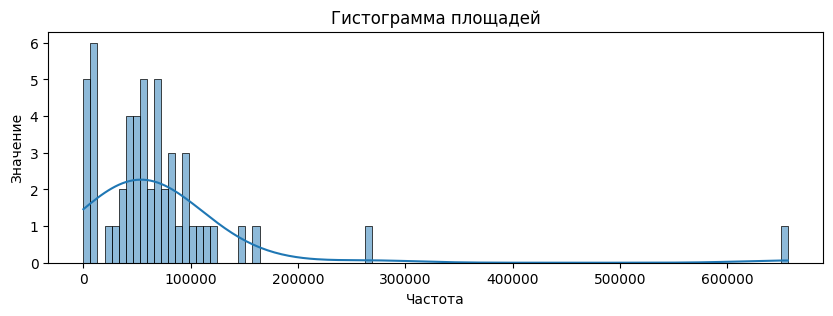

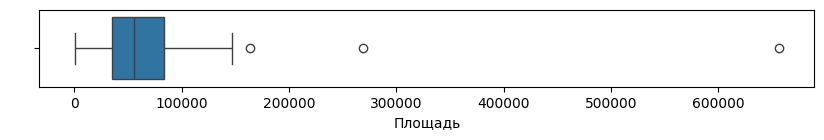

In [ ]:
# Построим гистограммы и ящик с усам площади.
plt.figure(figsize=(10, 3))
sns.histplot(data=df_areas, x="area (sq. mi)", kde=True, bins=100)
plt.title("Гистограмма площадей")
plt.xlabel("Частота")
plt.ylabel("Значение")
plt.show()

plt.figure(figsize=(10, 1))
sns.boxplot(x=df_areas["area (sq. mi)"])
plt.ylabel(" ")
plt.xlabel("Площадь")
plt.show()

# plt.subplot()

Такой же вариант графиков можно построить для населения.

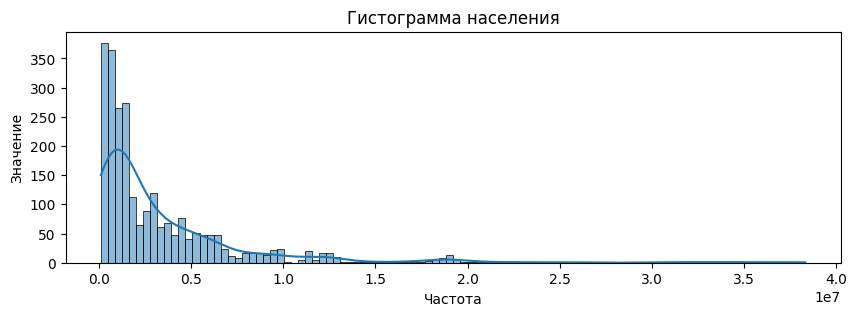

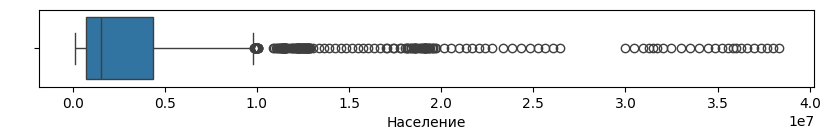

In [ ]:
# Построим гистограммы и ящик с усам площади.
plt.figure(figsize=(10, 3))
sns.histplot(data=df_population.loc[df_population['state/region'] != "USA"], x="population", kde=True, bins = 100)
plt.title("Гистограмма населения")
plt.xlabel("Частота")
plt.ylabel("Значение")
plt.show()

plt.figure(figsize=(10, 1))
sns.boxplot(x=df_population.loc[df_population['state/region'] != "USA", "population"])
plt.ylabel(" ")
plt.xlabel("Население")
plt.show()

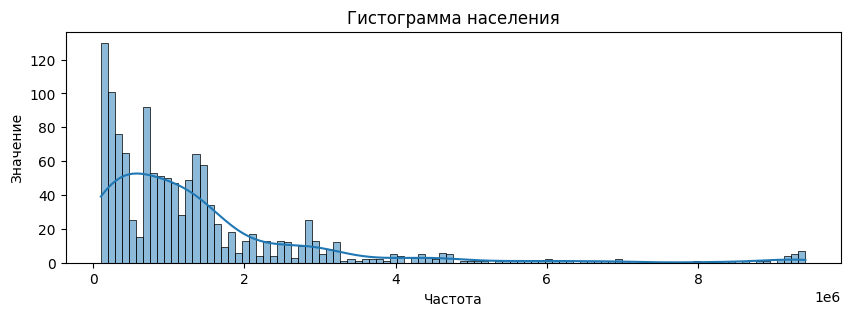

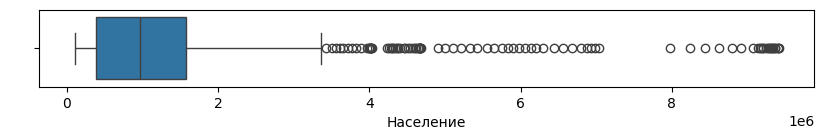

In [ ]:
# Построим гистограммы и ящик с усам площади.
plt.figure(figsize=(10, 3))
sns.histplot(data=df_population.loc[(df_population['state/region'] != "USA") & (df_population['ages']=='under18')], x="population", kde=True, bins = 100)
plt.title("Гистограмма населения")
plt.xlabel("Частота")
plt.ylabel("Значение")
plt.show()

plt.figure(figsize=(10, 1))
sns.boxplot(x=df_population.loc[(df_population['state/region'] != "USA") & (df_population['ages']=='under18'), "population"])
plt.ylabel(" ")
plt.xlabel("Население")
plt.show()

Первый пример того, что код это еще не все)
Предварительный вывод из данных графиков:
Какие то выводы достаточно сложно сделать из представленных графиков, поскольку графики не отображают никакой нужно информации. Для нахождения взаимосвязей и особенностей нужно придумать более "аналитические" варианты проверки.

А вот пример работы с датасетом, где корреляция, наоборот, говорит о многом.


In [ ]:
df_temp = pd.read_csv("real_estate_data.csv", sep='\t')
df_temp.corr(numeric_only=True).style.background_gradient(cmap='RdYlGn_r')

FileNotFoundError: [Errno 2] No such file or directory: 'real_estate_data.csv'

In [ ]:
df_temp

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,...,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,...,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,...,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,...,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


## 80 % работы аналитика - разумом, а не кодом.
Теперь представим ситуацию, как будто у нас отобрали компьютер, и необходимо порассуждать про данные без кода, пока просто на словах.
Итак, какие гипотезы можно выдвинуть, исходя из тех данных, которые имеются у нас на данный момент.
1. У нас есть население до 18 и после 18. Можно предположить, что такое население будет меняться по разному. И это логично, прирост по рождаемости, что я вляется основным показателем после миграции, дает прирост к населению именно до 18 лет. С другой стороны смертность, теоретически, сокращает население после 18. Стоит посмотреть, отличается динамика роста-сокращение населения.
2. Не всегда показатель числа людей может отображать объективные значения. Например, в большом городе живет намного больше людей, чем в маленьком. Но это не значит, что плотность населения будет больше в большом городе. Таким образом нельзя оценивать число людей - штаты могут отличаться по площади. В исследованиях лучше оценивать плотность населения, то есть количество человек, на одну квадраьную милю.
3. Стоит посмотреть, каким образом плотность населения изменяется в различных штатах, в разные годы в зависимости от возрастной категории.

Итак, введем в таблицу дополнительный столбец, в котором сформиреум плотность населения.

In [ ]:
# переименуем столбцы во избежания путаницы и ошибок
df_full.columns = ['state_region', 'ages','year' ,'population', 'state', 'area']

In [ ]:
# сделаем новый столбец с плотностью населения
df_full['pop_density'] = df_full['population']//df_full['area']

In [ ]:
df_full['pop_density'].describe()

,pop_density
count,2476.000000
mean,198.424475
std,863.826394
min,0.000000
25%,15.000000
50%,43.000000
75%,119.000000
max,9506.000000


Оценим среднюю плотность населения за все годы по возрастным группам

In [ ]:
# группируем данные по state_region и считаем среднюю и медианную плотность
# так же стоит исключить (пока) общие данные по USA
df_full_without_usa = df_full.loc[df_full['state_region']!='USA']
df_full_without_usa.groupby('ages').agg({'pop_density':['mean', 'median']})

pop_density       
               mean median
ages                      
total    326.602585   85.0
under18   70.246365   21.0

Предварительный вывод: стоит обратить внимание на то, что среднее и медиана очень сильно отличаются - это может говорить о том, что в данных могут присутсвовать явные перекосы. В данном случае сравнение происходит за все время и по всем штатам. Стоит посмотреть данные параметры в разрезе других категорий.

In [ ]:
df_full_without_usa.pivot_table(index = 'ages', columns = 'year', values = 'pop_density', aggfunc = ['mean'])

mean                                                  \
year           1990        1991        1992        1993        1994   
ages                                                                  
total    313.078431  313.098039  313.450980  314.274510  313.803922   
under18   65.901961   67.725490   68.764706   69.901961   70.941176   

                                                                     ...  \
year           1995        1996        1997        1998        1999  ...   
ages                                                                 ...   
total    312.568627  311.549020  311.549020  312.176471  314.980392  ...   
under18   71.725490   71.313725   71.078431   69.647059   70.294118  ...   

                                                                     \
year           2004        2005        2006        2007        2008   
ages                                                                  
total    328.038462  328.769231  330.673077  332.615385  335.192308   
under18   71.826923   70.942308   70.326923   69.769231   68.942308   

                                                                     
year           2009        2010        2011        2012        2013  
ages                                                                 
total    339.500000  344.076923  348.942308  353.538462  358.000000  
under18   68.769231   68.250000   68.673077   69.480769   70.307692  

[2 rows x 24 columns]

Такую таблицу оценивать крайне сложно, потому стоит построить график.

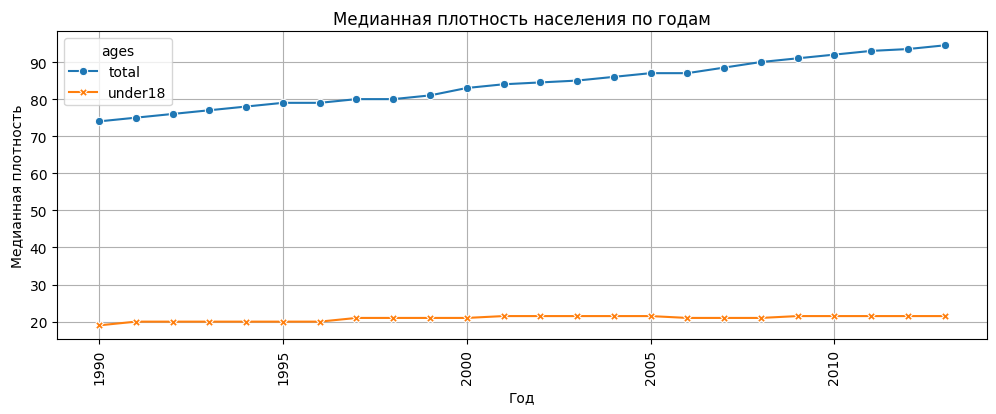

In [ ]:
df_gr = df_full_without_usa.groupby(['year', 'ages'], as_index=False).agg({'pop_density': 'median'})
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_gr, x='year', y='pop_density', hue = 'ages', markers=True, dashes=False, style="ages")
plt.grid()
plt.xticks(rotation=90)
plt.title("Медианная плотность населения по годам")
plt.xlabel("Год")
plt.ylabel("Медианная плотность")
plt.show()

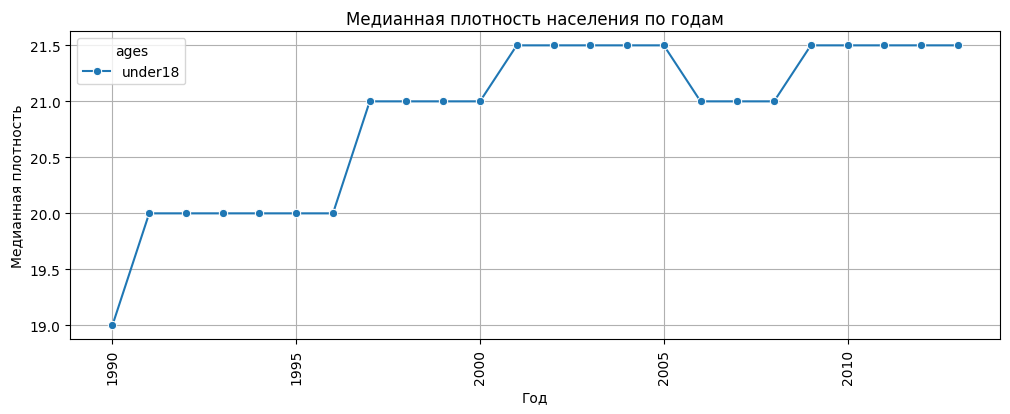

In [ ]:
df_gr_under18 = df_gr[df_gr['ages']=='under18']
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_gr_under18, x='year', y='pop_density', hue = 'ages', markers=True, dashes=False, style="ages")
plt.grid()
plt.xticks(rotation=90)
plt.title("Медианная плотность населения по годам")
plt.xlabel("Год")
plt.ylabel("Медианная плотность")
plt.show()

Промежуточный вывод. Картина теперь выглядит несколько нагляднее: теперь можно заметить, что при тенденции в рост общей плотности населения, плотность населения до 18 лет остается относительно стабильным из года в год. Можно выдвинуть гипотезу, почему так происходит:
1. Скорее всего миграция захватывает население старше 18 лет.
2. Каждый год некоторая прослойка молодого населения переходит в разряд "после 18". Это никак не влияет на показатель "total", однако влияет на показатель "до 18"
3. Комментарий про продолжительность ж

Теперь рассмотрим среднюю плотность населения по штатам, так же учитывая разделения по категории возраста.

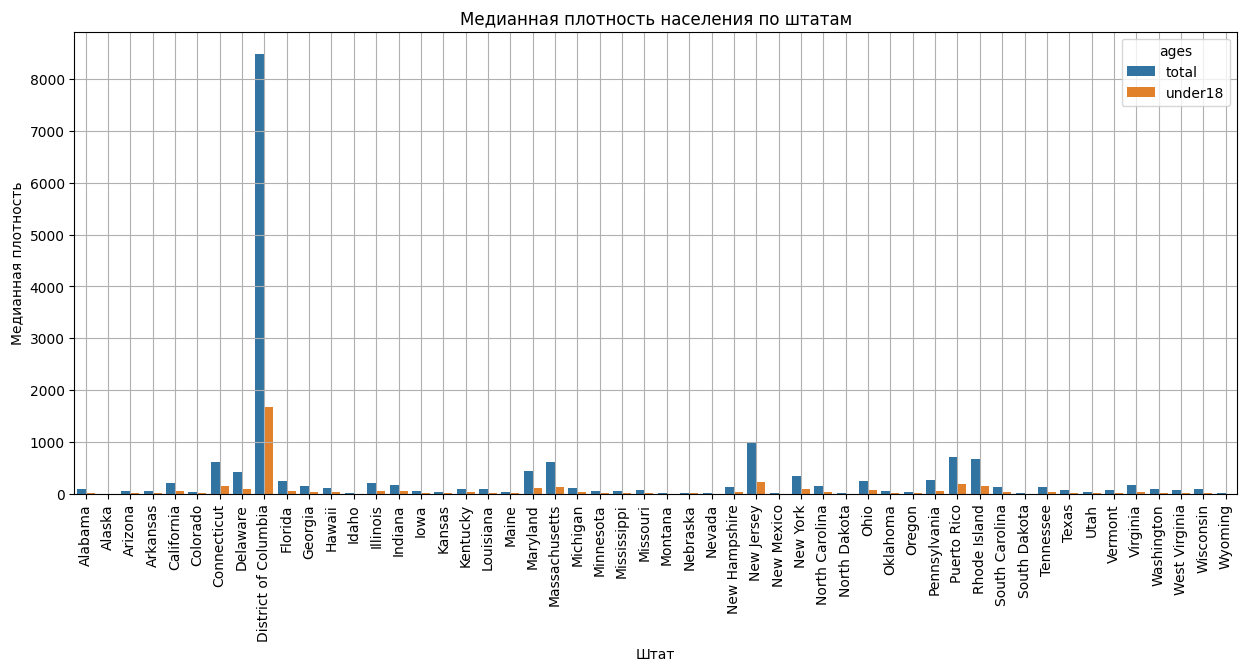

In [ ]:
df_gr = df_full_without_usa.groupby(['state', 'ages'], as_index=False).agg({'pop_density': 'median'})
plt.figure(figsize=(15, 6))
sns.barplot(data=df_gr, x='state', y='pop_density', hue = 'ages')#, markers=True, dashes=False, style="ages")
plt.grid()
plt.xticks(rotation=90)
plt.title("Медианная плотность населения по штатам")
plt.xlabel("Штат")
plt.ylabel("Медианная плотность")
plt.show()

Предварительный вывод. Самый высокий показатель плотности населения наблюдается в штате Коламбия. Некоторые штаты, такие как Мэрилэнд или Нью Джерси показывают так же большие показатели. Остальные штаты показывают примерно одинаковый результат, но стоит учитывать, что все штаты разные по размеру, стоит проверить, насколько размер штата влияет на плотность населения и как размер влияет на численность молодого поколения.

Стоит проверить данные за последние пять лет и за последний год, во избежание перекосов за предыдущие годы.

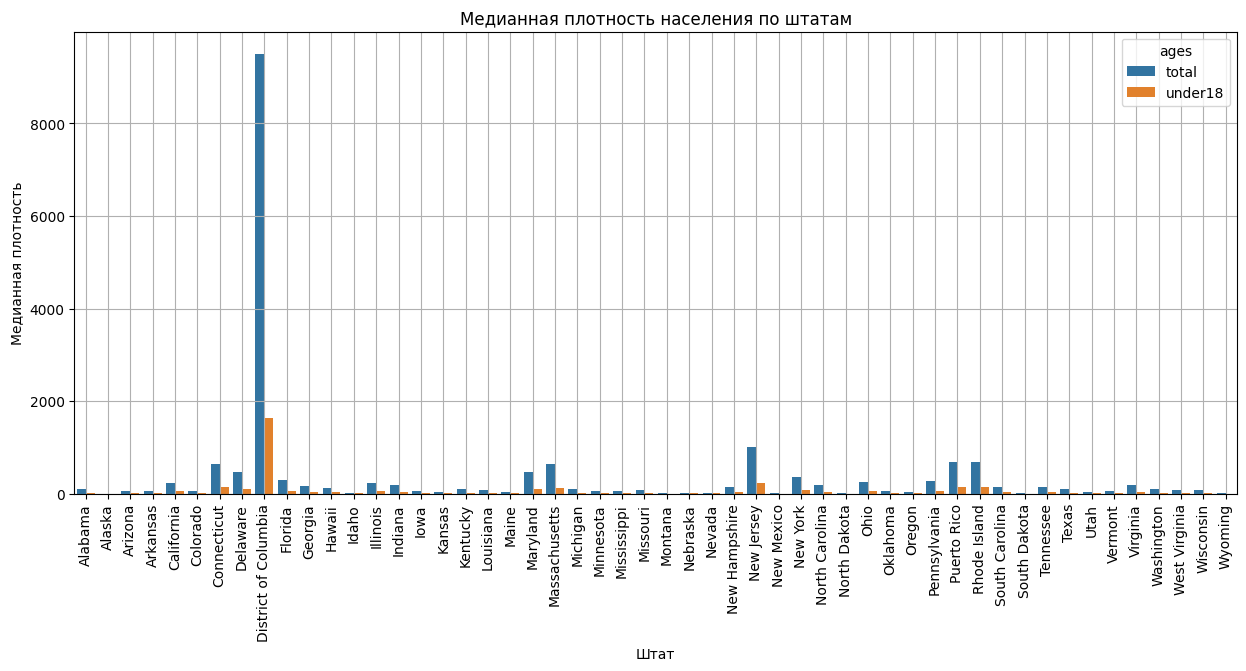

In [ ]:
df_gr = df_full_without_usa[df_full_without_usa['year'].isin([2013])]\
.groupby(['state', 'ages'], as_index=False).agg({'pop_density': 'median'})
plt.figure(figsize=(15, 6))
sns.barplot(data=df_gr, x='state', y='pop_density', hue = 'ages')#, markers=True, dashes=False, style="ages")
plt.grid()
plt.xticks(rotation=90)
plt.title("Медианная плотность населения по штатам")
plt.xlabel("Штат")
plt.ylabel("Медианная плотность")
plt.show()

Оценивать штаты по площади достаточно сложно, потому стоит ввести категории размера штатов.

In [ ]:
df_full_without_usa["area_category_qcut"] = pd.qcut(
    df_full_without_usa["area"],
    q=5,
    labels=["Очень малый штат", "Малый штат", "Средний штат", "Большой штат", "Очень большой штат"],
)
df_full_without_usa

,state_region,ages,year,population,state,area,pop_density,area_category_qcut
0,AL,under18,2012,1117489.0,Alabama,52423.0,21.0,Средний штат
1,AL,total,2012,4817528.0,Alabama,52423.0,91.0,Средний штат
2,AL,under18,2010,1130966.0,Alabama,52423.0,21.0,Средний штат
3,AL,total,2010,4785570.0,Alabama,52423.0,91.0,Средний штат
4,AL,under18,2011,1125763.0,Alabama,52423.0,21.0,Средний штат
...,...,...,...,...,...,...,...,...
2471,PR,under18,2010,896945.0,Puerto Rico,5325.0,168.0,Очень малый штат
2472,PR,under18,2011,869327.0,Puerto Rico,5325.0,163.0,Очень малый штат
2473,PR,total,2011,3686580.0,Puerto Rico,5325.0,692.0,Очень малый штат
2474,PR,under18,2012,841740.0,Puerto Rico,5325.0,158.0,Очень малый штат


Теперь можно ценить те же показатели в зависимости от размера штата.

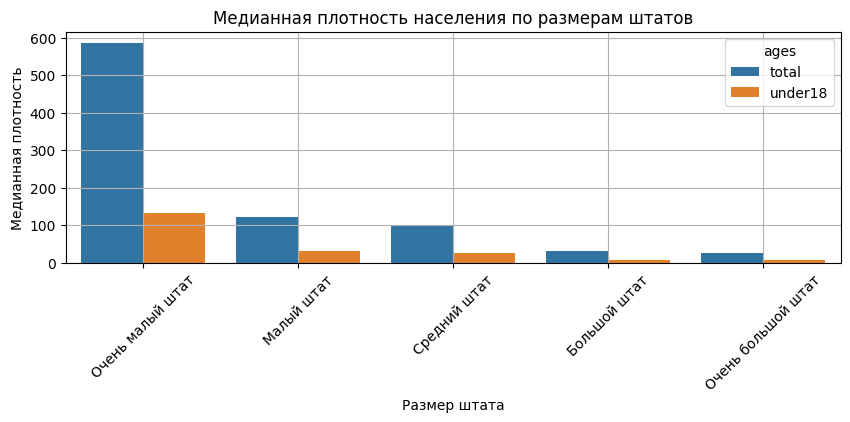

In [ ]:
df_gr = df_full_without_usa.groupby(['area_category_qcut', 'ages'], as_index=False).agg({'pop_density': 'median'})
plt.figure(figsize=(10, 3))
sns.barplot(data=df_gr, x='area_category_qcut', y='pop_density', hue = 'ages')#, markers=True, dashes=False, style="ages")
plt.grid()
plt.xticks(rotation=45)
plt.title("Медианная плотность населения по размерам штатов")
plt.xlabel("Размер штата")
plt.ylabel("Медианная плотность")
plt.show()

Предварительный вывод. Оценка показывает, что чем больше штат, тем меньше у него плотность населения. Это относится как к молодому населению, так и к населению в целом.

Теперь рассмотрим динамику изменения населения в разрезе размеров штатов.

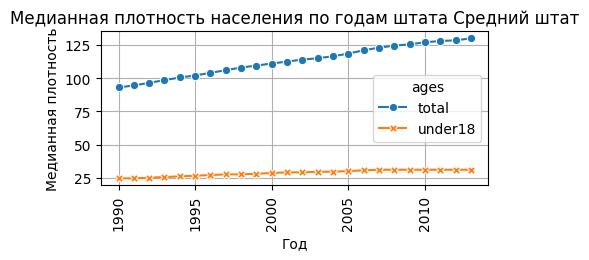

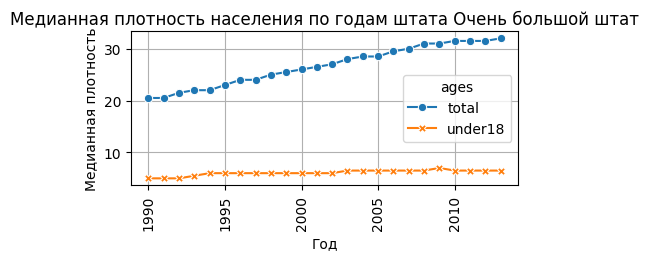

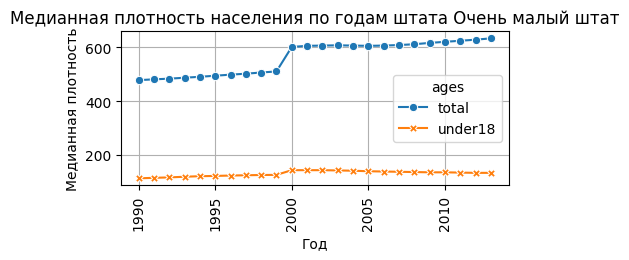

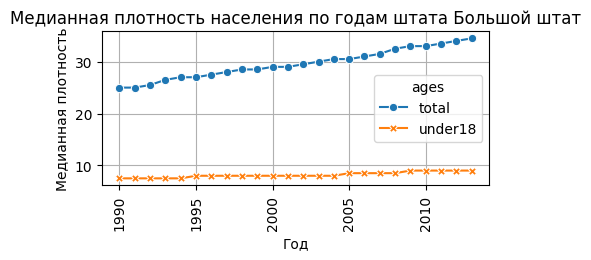

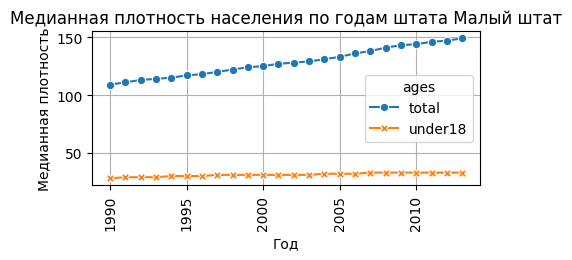

In [ ]:
for i in df_full_without_usa['area_category_qcut'].unique():
    df_gr = df_full_without_usa[df_full_without_usa['area_category_qcut'] == i].groupby(['year', 'ages'], as_index=False).agg({'pop_density': 'median'})
    plt.figure(figsize=(5, 2))
    sns.lineplot(data=df_gr, x='year', y='pop_density', hue = 'ages', markers=True, dashes=False, style="ages")
    plt.grid()
    plt.xticks(rotation=90)
    plt.title("Медианная плотность населения по годам штата " + i)
    plt.xlabel("Год")
    plt.ylabel("Медианная плотность")
    plt.show()

Предварительный вывод: В разрезе размеров штатов, заметно, что динамика практически не отличается от общей картины, кроме очень малых штатов. При высокой плотности населения, после 2000 года, где был зафиксирован скачек в увеличении плотности населения, как молодежи так и в целом. Возможно, это связано с нейкими гос. программами или экономическим ростом. После чего наблюдается раст населения в целом, при этом население до 18 лет показывает стабильное падение.
Это может ыть вполне логичным: высокая плотность населения создает дифицит рабочих мест, провоцирует нехватку жилья. Такие проблемы не позволяют семьям заводить детей, что влияет на динамику падения молодого населения.
Стоит уточнить результат, рассмотрев тенденцию для каждого штата отдельности.



Теперь можно рассмотреть эту тенденцию в разрезе штатов, чтоб убедиться, что резкая динамика какого либо штат не влияет на картину в целом.

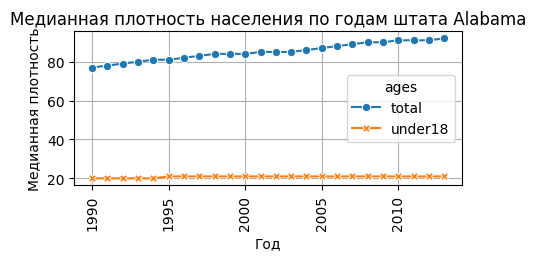

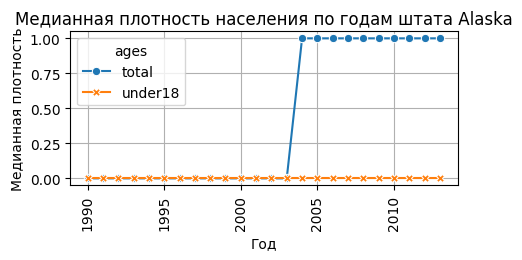

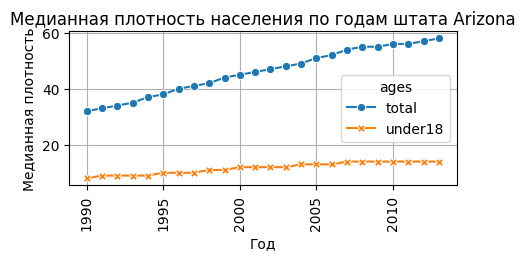

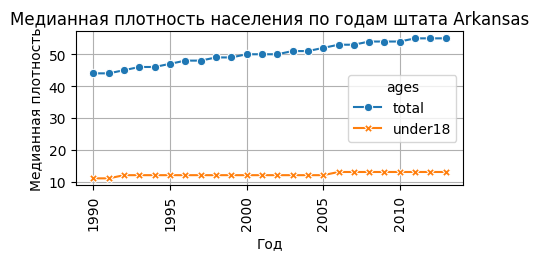

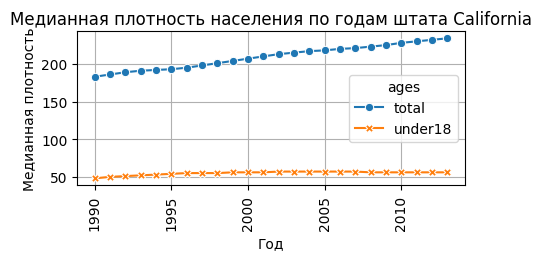

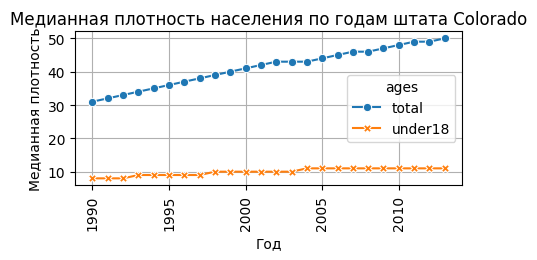

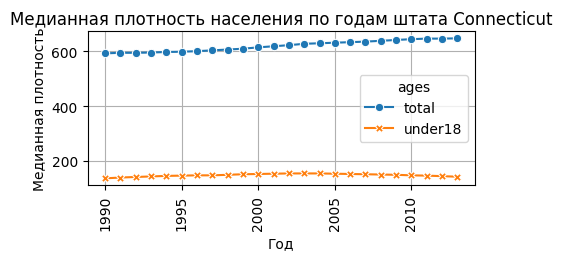

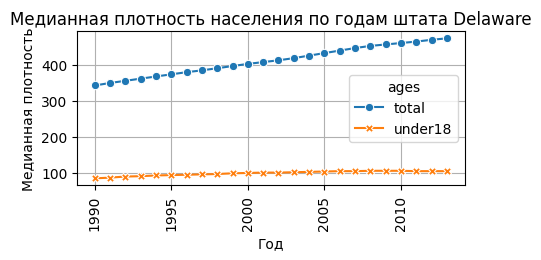

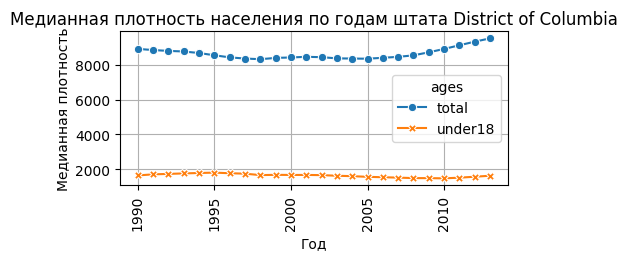

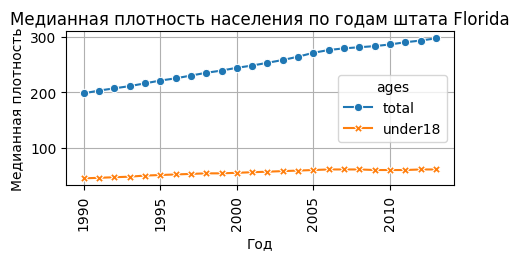

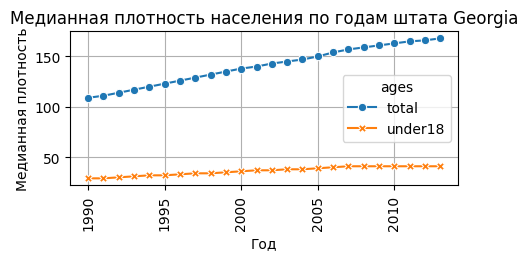

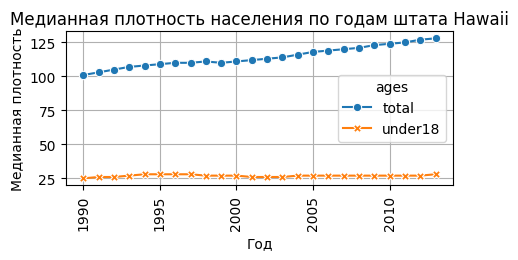

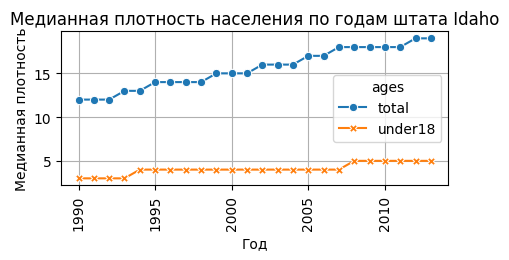

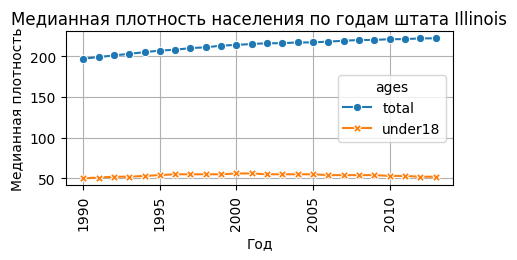

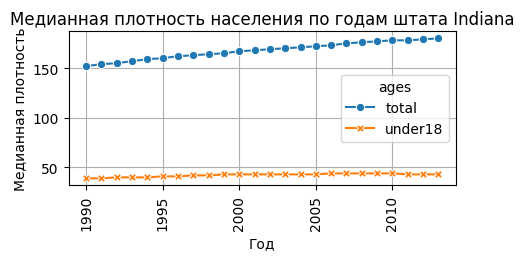

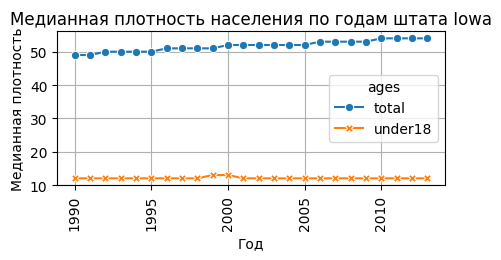

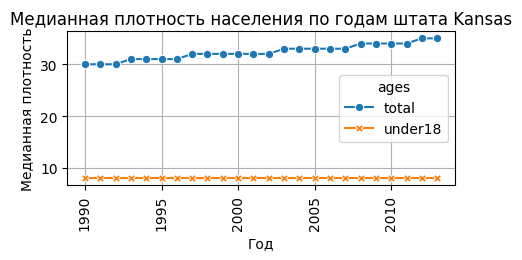

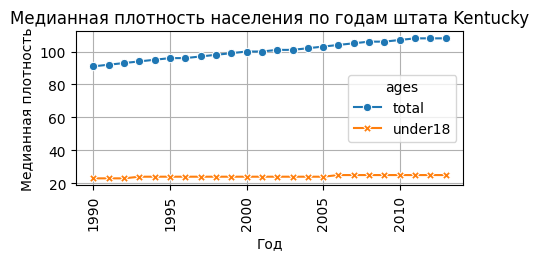

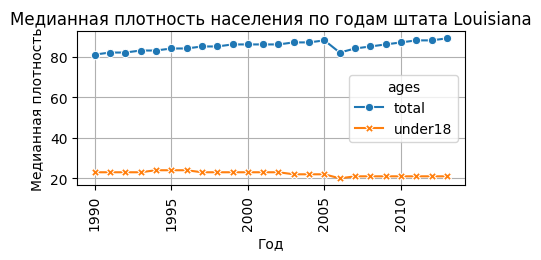

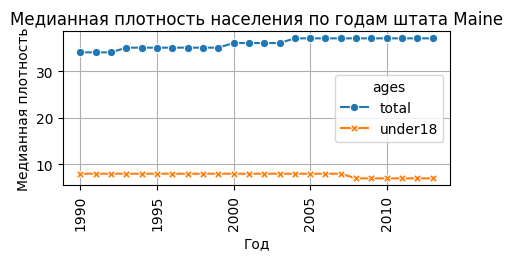

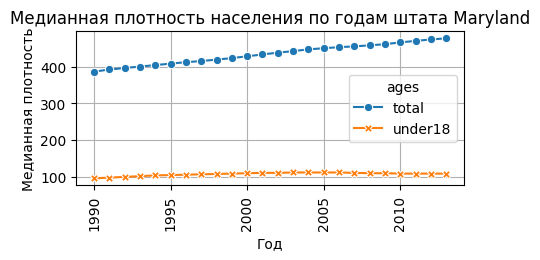

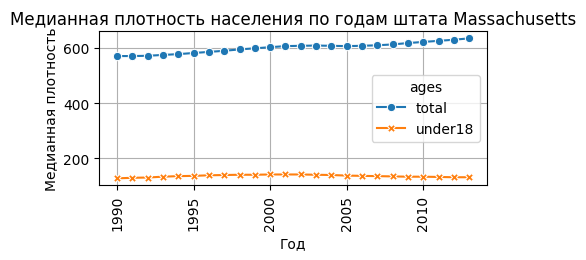

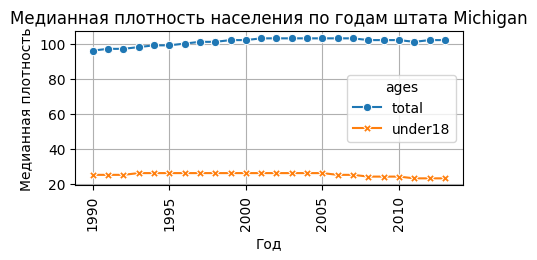

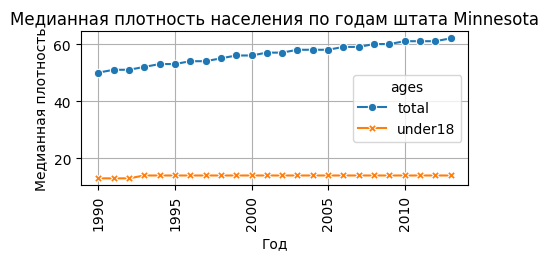

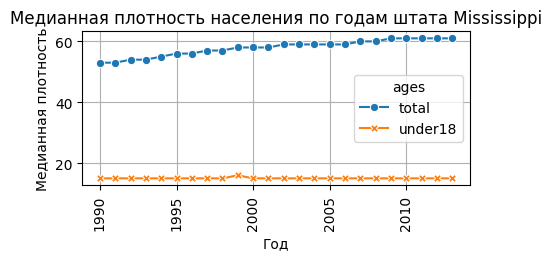

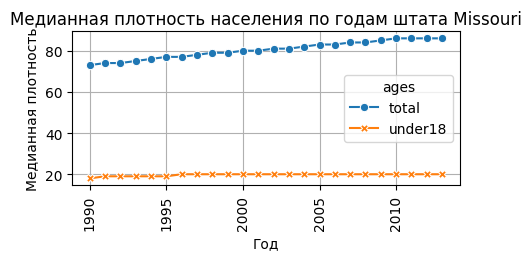

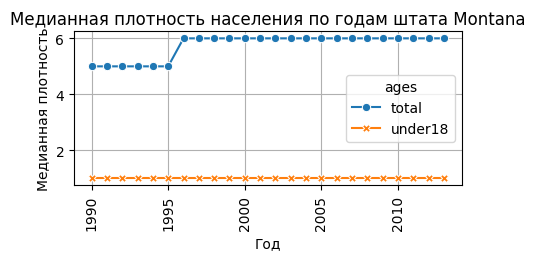

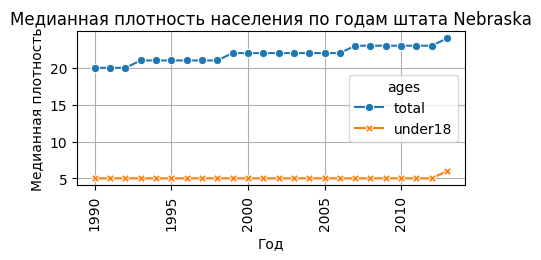

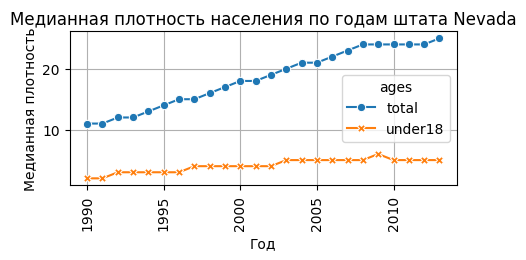

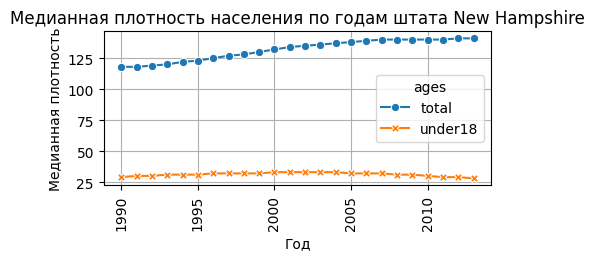

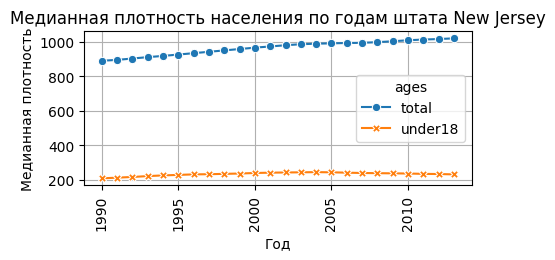

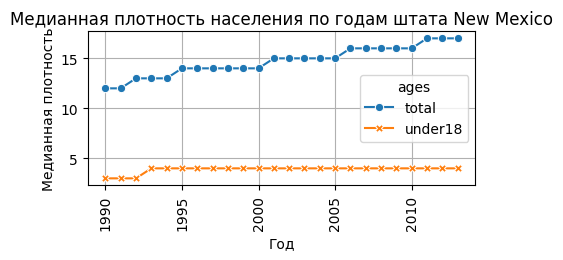

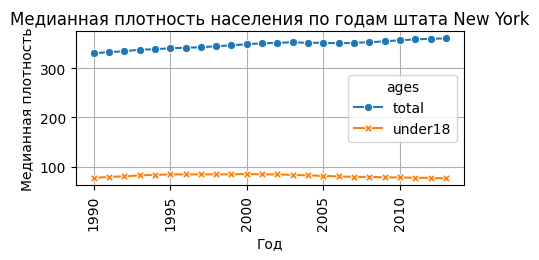

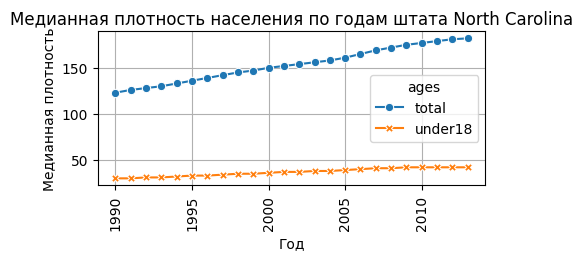

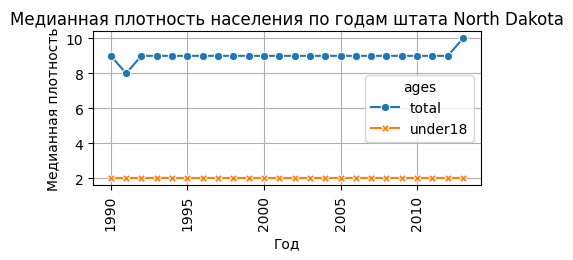

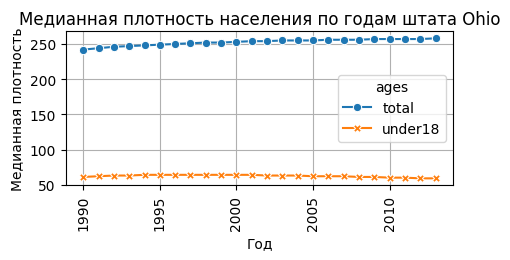

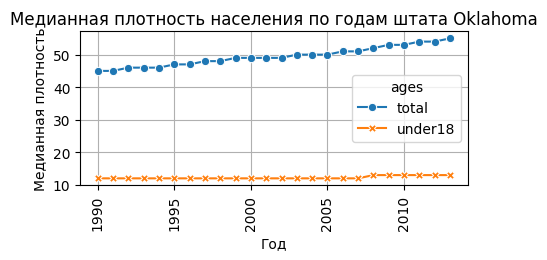

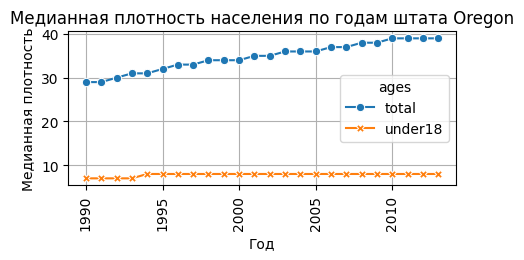

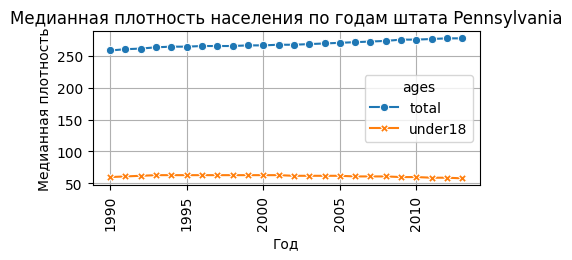

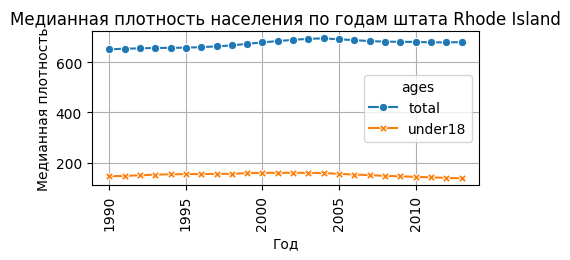

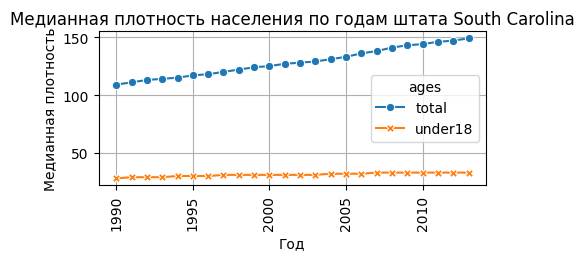

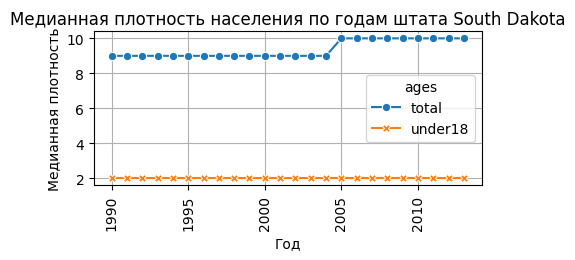

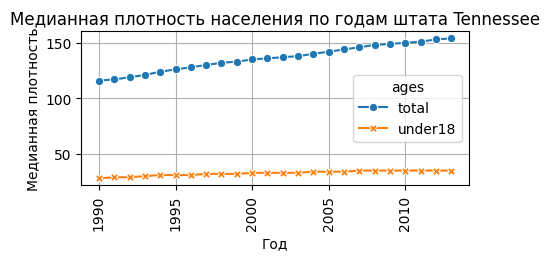

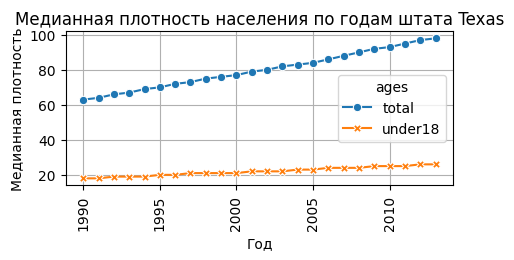

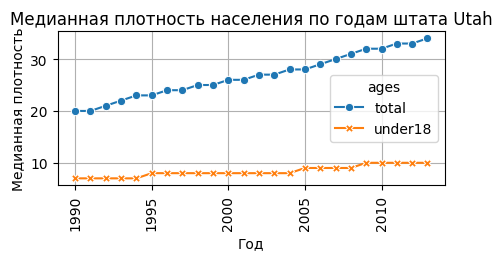

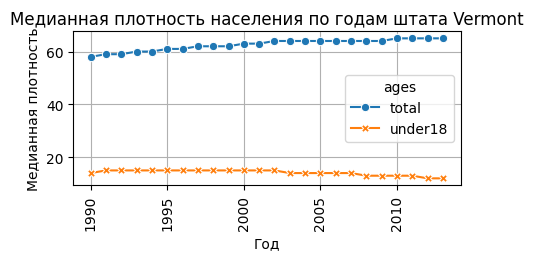

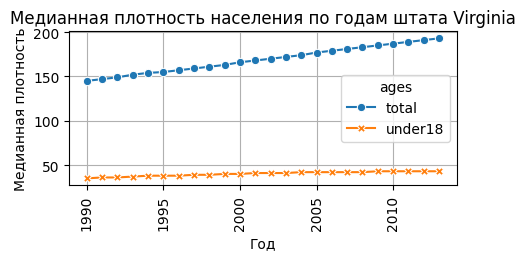

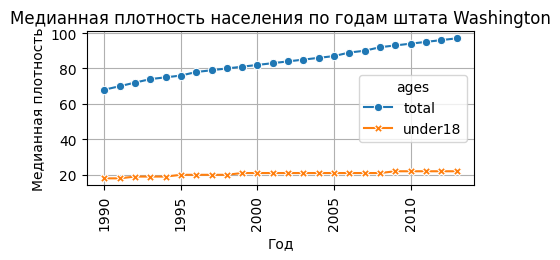

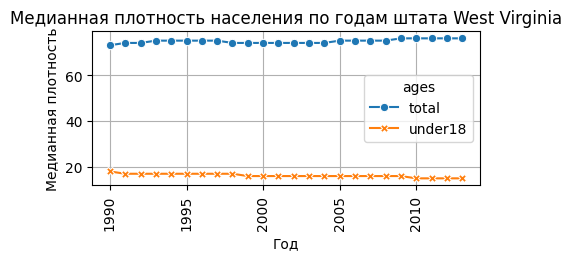

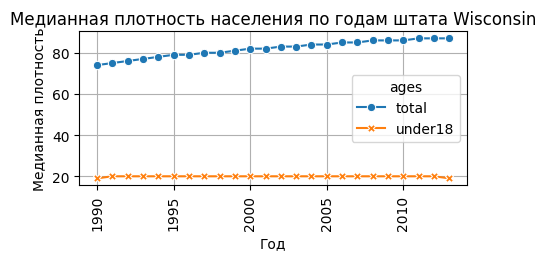

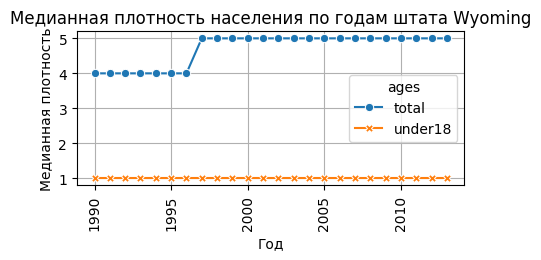

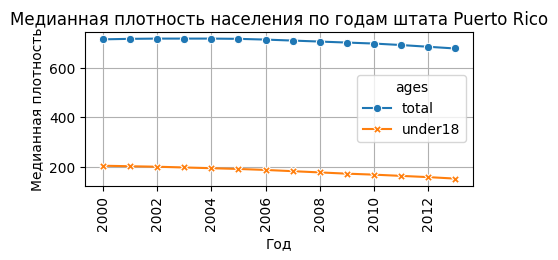

In [ ]:
for i in df_full_without_usa['state'].unique():
    df_gr = df_full_without_usa[df_full_without_usa['state'] == i].groupby(['year', 'ages'], as_index=False).agg({'pop_density': 'median'})
    plt.figure(figsize=(5, 2))
    sns.lineplot(data=df_gr, x='year', y='pop_density', hue = 'ages', markers=True, dashes=False, style="ages")
    plt.grid()
    plt.xticks(rotation=90)
    plt.title("Медианная плотность населения по годам штата " + i)
    plt.xlabel("Год")
    plt.ylabel("Медианная плотность")
    plt.show()

Отдельных перекосов не наблюдается, можно сказать, что предыдущие рассуждения в целом верные.

Теперь оценим процентное отношение молодого поколения к общему числу населения (но теперь уже используя количество, а не плотность)

Введём дополнительный столбец с процентом молодого населения. В разрезе данных, можно сразу подсчитать процен для каждого штата и года.

In [ ]:
df_percent_young = df_full_without_usa.pivot_table(index = ['year', 'state'],
                                                   columns = 'ages',
                                                   values = 'population',
                                                   aggfunc = 'sum').reset_index()
df_percent_young.columns = ['year', 'state', 'total', 'under18']
df_percent_young['percent_young'] = round(df_percent_young['under18']/df_percent_young['total']*100,2)
df_percent_young.pivot_table(index = 'state',
                                columns = 'year',
                                values = 'percent_young',
                                aggfunc = 'mean').reset_index().style.background_gradient(cmap='Greens')

year,state,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Alabama,25.930000,25.880000,25.830000,25.760000,25.750000,25.850000,25.680000,25.710000,25.390000,25.310000,25.210000,25.080000,24.920000,24.720000,24.580000,24.450000,24.340000,24.230000,24.050000,23.840000,23.630000,23.450000,23.200000,22.990000
1,Alaska,32.080000,31.950000,31.400000,31.230000,31.070000,30.610000,30.460000,30.720000,31.070000,30.640000,30.350000,29.790000,29.340000,28.820000,28.260000,27.780000,27.480000,27.100000,26.640000,26.660000,26.320000,26.030000,25.760000,25.590000
2,Arizona,27.310000,27.140000,26.960000,26.920000,26.380000,26.470000,26.490000,26.120000,26.330000,26.520000,26.610000,26.530000,26.460000,26.380000,26.260000,26.190000,26.120000,26.070000,25.930000,25.660000,25.410000,24.990000,24.680000,24.400000
3,Arkansas,26.350000,26.280000,26.420000,26.200000,26.220000,26.330000,26.360000,26.150000,26.030000,25.720000,25.400000,25.250000,25.090000,24.940000,24.850000,24.800000,24.730000,24.670000,24.550000,24.440000,24.360000,24.180000,24.090000,23.990000
4,California,26.640000,27.060000,27.250000,27.580000,27.920000,28.140000,28.360000,28.120000,27.780000,27.490000,27.270000,27.050000,26.860000,26.680000,26.480000,26.250000,26.010000,25.750000,25.470000,25.150000,24.870000,24.560000,24.230000,23.930000
5,Colorado,26.650000,26.470000,26.480000,26.230000,25.950000,25.720000,25.610000,25.650000,25.750000,25.650000,25.580000,25.460000,25.350000,25.270000,25.060000,24.970000,24.820000,24.760000,24.610000,24.480000,24.300000,24.030000,23.760000,23.500000
6,Connecticut,22.860000,23.200000,23.550000,23.900000,24.160000,24.330000,24.330000,24.310000,24.500000,24.650000,24.690000,24.640000,24.540000,24.430000,24.280000,24.070000,23.860000,23.630000,23.310000,23.050000,22.750000,22.430000,22.130000,21.850000
7,Delaware,24.740000,24.870000,25.060000,25.050000,25.200000,24.900000,24.830000,24.830000,24.800000,24.840000,24.790000,24.640000,24.430000,24.210000,24.030000,23.900000,23.710000,23.530000,23.320000,23.130000,22.840000,22.560000,22.310000,21.990000
8,District of Columbia,18.610000,19.440000,19.850000,20.240000,20.730000,21.290000,21.180000,21.050000,20.140000,20.170000,20.020000,19.950000,19.860000,19.600000,19.330000,18.900000,18.510000,18.130000,17.620000,17.240000,16.740000,16.770000,16.990000,17.240000
9,Florida,22.930000,22.780000,22.860000,23.080000,23.170000,23.160000,23.100000,23.060000,22.970000,22.920000,22.780000,22.710000,22.620000,22.470000,22.340000,22.240000,22.140000,21.950000,21.690000,21.430000,21.220000,20.970000,20.770000,20.590000


Предварительные выводы: Картина не равномерная, существует достаточно много штатов, которые отличаются по количеству населения.

Оценим тенденцию, как меняется процент молодежи по годам в самых "молодых" штатах.

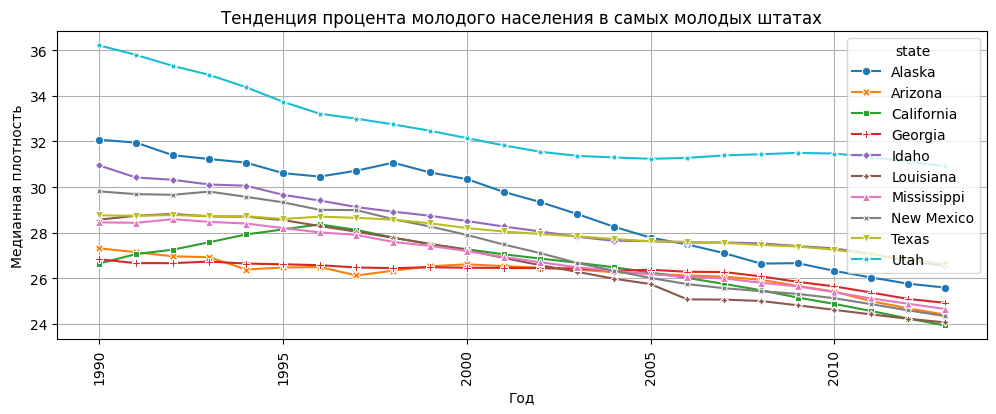

In [ ]:
df_percent_young_top = df_percent_young.groupby('state', as_index = False)['percent_young'].median()\
                       .sort_values(by = 'percent_young', ascending = False).head(10)['state'].to_list()
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_percent_young[df_percent_young['state'].isin(df_percent_young_top)],
             x='year', y='percent_young', hue = 'state', markers=True, dashes=False, style="state")
plt.grid()
plt.xticks(rotation=90)
plt.title("Тенденция процента молодого населения в самых молодых штатах")
plt.xlabel("Год")
plt.ylabel("Медианная плотность")
plt.show()

Тенденция очень четкая: процент молодежи имеет тенденцию к падению в самых "молодых" штатах.

Посмотрим на тенденцию в очень малых штатах.



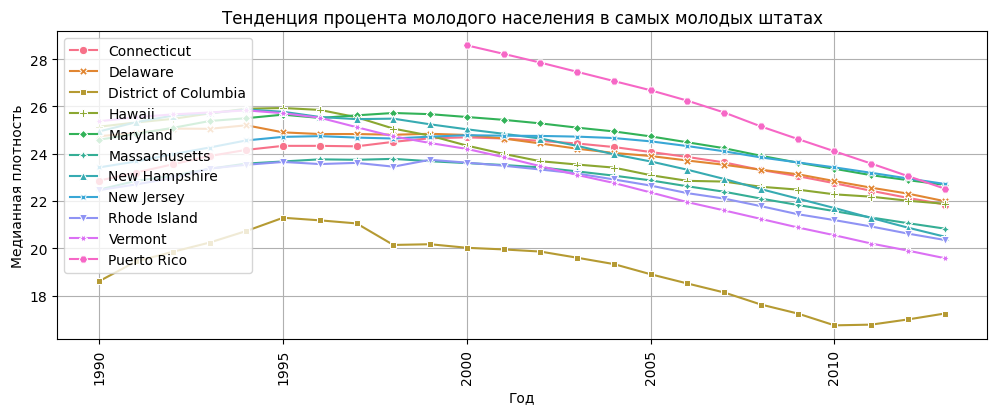

In [ ]:
list_state_xs = df_full_without_usa[df_full_without_usa['area_category_qcut'] == 'Очень малый штат']['state'].unique()
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_percent_young[df_percent_young['state'].isin(list_state_xs)],
             x='year', y='percent_young', hue = 'state', markers=True, dashes=False, style="state")
plt.grid()
plt.xticks(rotation=90)
plt.title("Тенденция процента молодого населения в самых молодых штатах")
plt.xlabel("Год")
plt.ylabel("Медианная плотность")
plt.legend(loc = 'upper left')
plt.show()